# ARI Pipeline

## Data & Packages

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24

# Time aggregation
agg_hour_level = 6

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

# Silhouette sample size 
sample_size = 1000

In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

In [8]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)   
    db  = davies_bouldin_score(Y, labels)    
    
    return k, sil,ch,db

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

## Clustering 

In [10]:
# Cluster for each week
n_weeks = 8
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    results = Parallel(n_jobs = -1)(delayed(fit_kmeans)(k, X_scaled, sample_size) for k in range(2,11))

    best_result = max(results, key = lambda row: row[1])
    best_k, best_score  = best_result[0], best_result[1]

    print(f"Week {week}: optimal k = {best_k}, silhouette = {best_score:.4f}")

    km = KMeans(n_clusters=best_k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    features_week.write_parquet(f'/home/ma/t/tr725/MSc-Project/03_working_notebooks/results/week{week}.parquet')

    weekly_results[week] = features_week


Week 1: optimal k = 2, silhouette = 0.4543
Week 2: optimal k = 2, silhouette = 0.4563
Week 3: optimal k = 2, silhouette = 0.4527
Week 4: optimal k = 2, silhouette = 0.4598
Week 5: optimal k = 6, silhouette = 0.4344
Week 6: optimal k = 2, silhouette = 0.4312
Week 7: optimal k = 2, silhouette = 0.4318
Week 8: optimal k = 6, silhouette = 0.4517


# Adjusted Rand Index

In [11]:
# ARI (clustering stability )scores
ARI_scores = {}

for week in range(1, n_weeks):

    w_curr = weekly_results[week].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket = pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next,on = ['src_user','relative_bucket'],how = 'inner',suffix = '_next')


    labels_curr = overlap['cluster'].to_numpy()
    labels_next =  overlap['cluster_next'].to_numpy()
    
    ARI = adjusted_rand_score(labels_curr, labels_next)

    ARI_scores[(week, week + 1)] = ARI

    print(f"ARI week {week}→{week+1}: {ARI:.4f}")
    print(f"  Overlap: {len(overlap)} / {len(w_curr)} week {week} pairs ({len(overlap)/len(w_curr):.2%})")

ARI week 1→2: 0.7387
  Overlap: 141712 / 179408 week 1 pairs (78.99%)
ARI week 2→3: 0.7299
  Overlap: 143750 / 199818 week 2 pairs (71.94%)
ARI week 3→4: 0.7300
  Overlap: 145464 / 178272 week 3 pairs (81.60%)
ARI week 4→5: 0.0888
  Overlap: 160811 / 198621 week 4 pairs (80.96%)
ARI week 5→6: 0.0962
  Overlap: 158552 / 201635 week 5 pairs (78.63%)
ARI week 6→7: 0.7476
  Overlap: 147642 / 201839 week 6 pairs (73.15%)
ARI week 7→8: 0.1126
  Overlap: 145471 / 197366 week 7 pairs (73.71%)


In [12]:
ARI_scores

{(1, 2): 0.7387187482505845,
 (2, 3): 0.7299094666186589,
 (3, 4): 0.7299660350389174,
 (4, 5): 0.08883263017090401,
 (5, 6): 0.09620162157914315,
 (6, 7): 0.747593035175545,
 (7, 8): 0.11262826909378505}

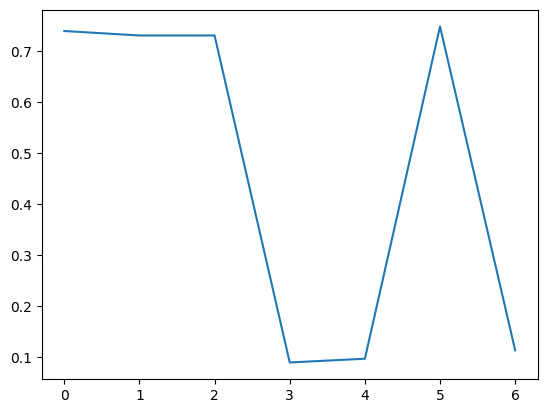

In [13]:
plt.plot(ARI_scores.values())

If we are just in intreseted in the stability of each time aggregation, not the raw numbers, how do we say something is more stable than another. For exmaple if one aggregation had a high value but that varied more, than a low value that varied less.